# Лабораторная работа №4

**Вариант 1**


In [1]:
from pathlib import Path
import shutil

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["figure.dpi"] = 120

SELECTED_NAMES = ["01.png", "02.png"]
THRESHOLD = 35

GX_KERNEL = np.array([
    [0, 0, 0],
    [0, -1, 0],
    [0, 0, 1],
], dtype=np.float32)

GY_KERNEL = np.array([
    [0, 0, 0],
    [0, -1, 0],
    [0, 0, 1],
], dtype=np.float32)

base_candidates = [Path.cwd(), Path.cwd() / "lab4_project"]
BASE = next((path for path in base_candidates if (path / "source_png").exists()), base_candidates[0])

LAB2_SOURCE_DIR = BASE.parent / "lab2" / "lab2_variant17" / "source_png"
SOURCE_DIR = BASE / "source_png"
GRAY_DIR = BASE / "gray_png"
GRADIENT_DIR = BASE / "gradient_png"
BINARY_DIR = BASE / "binary_png"

for folder in [SOURCE_DIR, GRAY_DIR, GRADIENT_DIR, BINARY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
    for old_file in folder.glob("*.png"):
        old_file.unlink()

files = [LAB2_SOURCE_DIR / name for name in SELECTED_NAMES]
missing = [path.name for path in files if not path.exists()]
if missing:
    raise FileNotFoundError(f"Не найдены исходные файлы: {missing}")

for path in files:
    shutil.copy2(path, SOURCE_DIR / path.name)

files = [SOURCE_DIR / name for name in SELECTED_NAMES]

print("Gx =\n", GX_KERNEL)
print("Gy =\n", GY_KERNEL)
print("Используются файлы:", [path.name for path in files])


Gx =
 [[ 0.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]
Gy =
 [[ 0.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]
Используются файлы: ['01.png', '02.png']


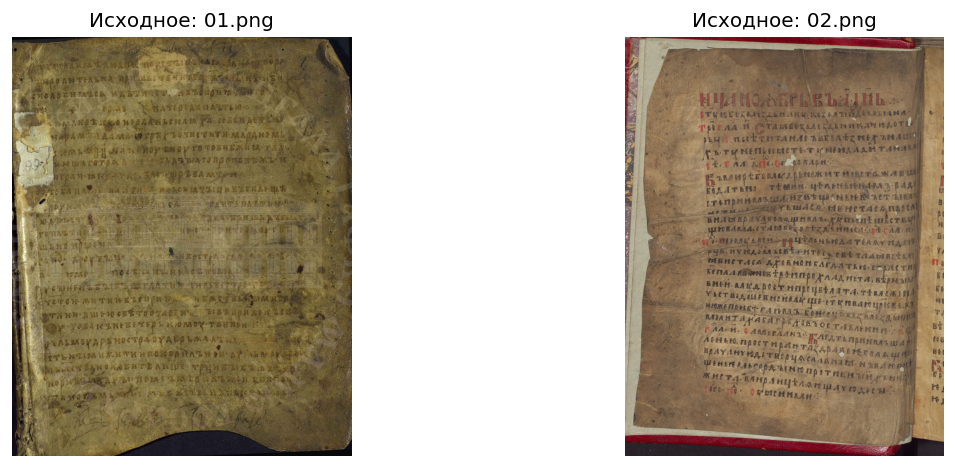

In [2]:
fig, axes = plt.subplots(1, len(files), figsize=(6 * len(files), 4))
if len(files) == 1:
    axes = [axes]

for ax, path in zip(axes, files):
    image = np.array(Image.open(path).convert("RGB"))
    ax.imshow(image)
    ax.set_title(f"Исходное: {path.name}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [3]:
def rgb_to_gray(rgb):
    rgb = rgb.astype(np.float32)
    gray = 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    return np.clip(np.round(gray), 0, 255).astype(np.uint8)


def normalize(image):
    image = image.astype(np.float32)
    image_min = image.min()
    image_max = image.max()
    if image_max - image_min < 1e-6:
        return np.zeros_like(image, dtype=np.uint8)
    image = (image - image_min) * 255.0 / (image_max - image_min)
    return np.round(image).astype(np.uint8)


def apply_kernel(gray, kernel):
    gray = gray.astype(np.float32)
    padded = np.pad(gray, 1, mode="edge")
    out = (
        kernel[0, 0] * padded[:-2, :-2]
        + kernel[0, 1] * padded[:-2, 1:-1]
        + kernel[0, 2] * padded[:-2, 2:]
        + kernel[1, 0] * padded[1:-1, :-2]
        + kernel[1, 1] * padded[1:-1, 1:-1]
        + kernel[1, 2] * padded[1:-1, 2:]
        + kernel[2, 0] * padded[2:, :-2]
        + kernel[2, 1] * padded[2:, 1:-1]
        + kernel[2, 2] * padded[2:, 2:]
    )
    return out


def roberts(gray):
    gx = apply_kernel(gray, GX_KERNEL)
    gy = apply_kernel(gray, GY_KERNEL)
    g = np.sqrt(gx ** 2 + gy ** 2)
    return gx, gy, g


In [4]:
processed = []

for path in files:
    rgb = np.array(Image.open(path).convert("RGB"))
    gray = rgb_to_gray(rgb)
    gx, gy, g = roberts(gray)

    gray_img = gray
    gx_img = normalize(gx)
    gy_img = normalize(gy)
    g_img = normalize(g)
    binary = np.where(g_img >= THRESHOLD, 255, 0).astype(np.uint8)

    Image.fromarray(gray_img, mode="L").save(GRAY_DIR / path.name)
    Image.fromarray(gx_img, mode="L").save(GRADIENT_DIR / f"{path.stem}_gx.png")
    Image.fromarray(gy_img, mode="L").save(GRADIENT_DIR / f"{path.stem}_gy.png")
    Image.fromarray(g_img, mode="L").save(GRADIENT_DIR / f"{path.stem}_g.png")
    Image.fromarray(binary, mode="L").save(BINARY_DIR / path.name)

    processed.append((path.name, rgb, gray_img, gx_img, gy_img, g_img, binary))

print("Готово:", len(processed))


Готово: 2


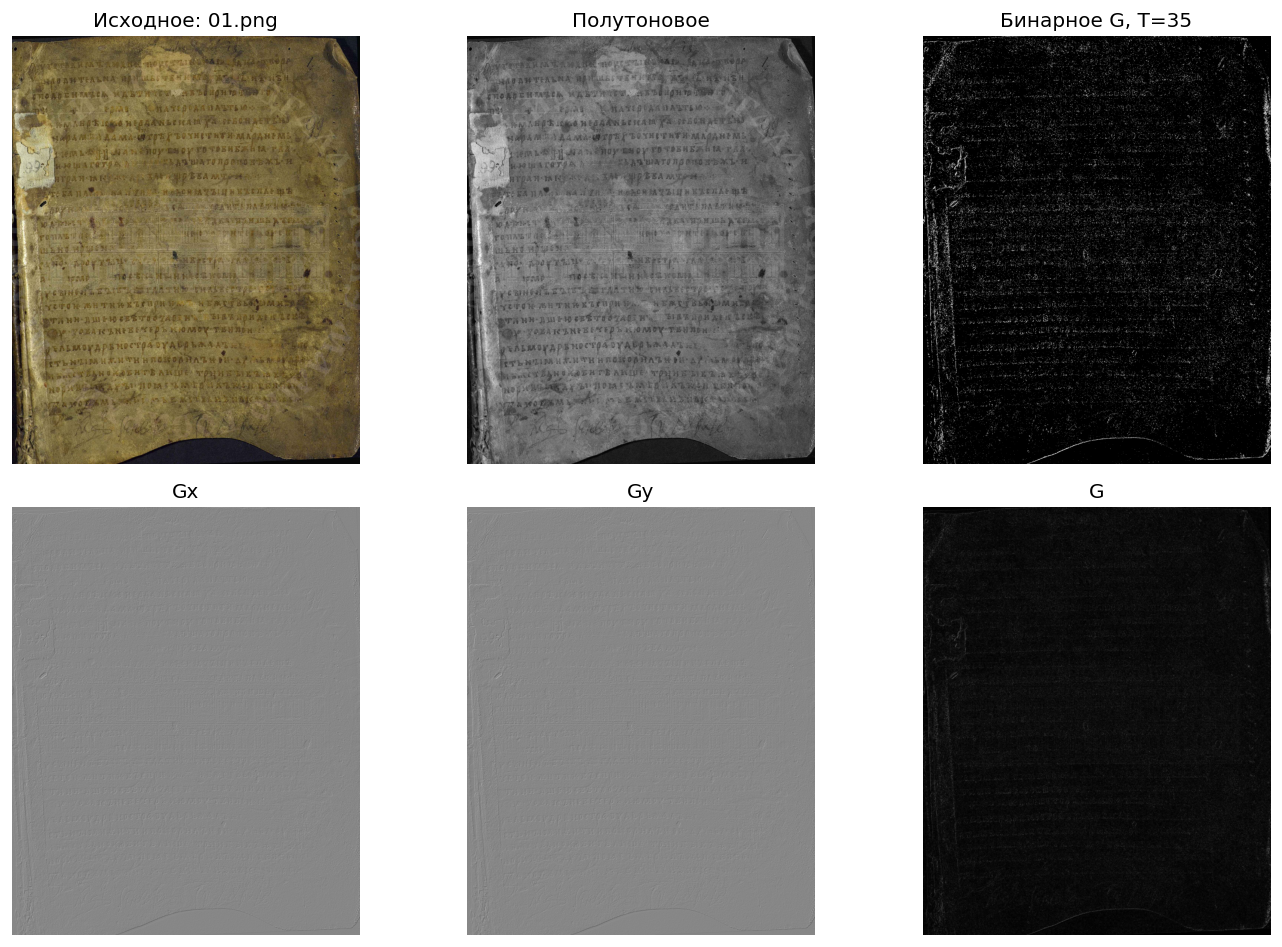

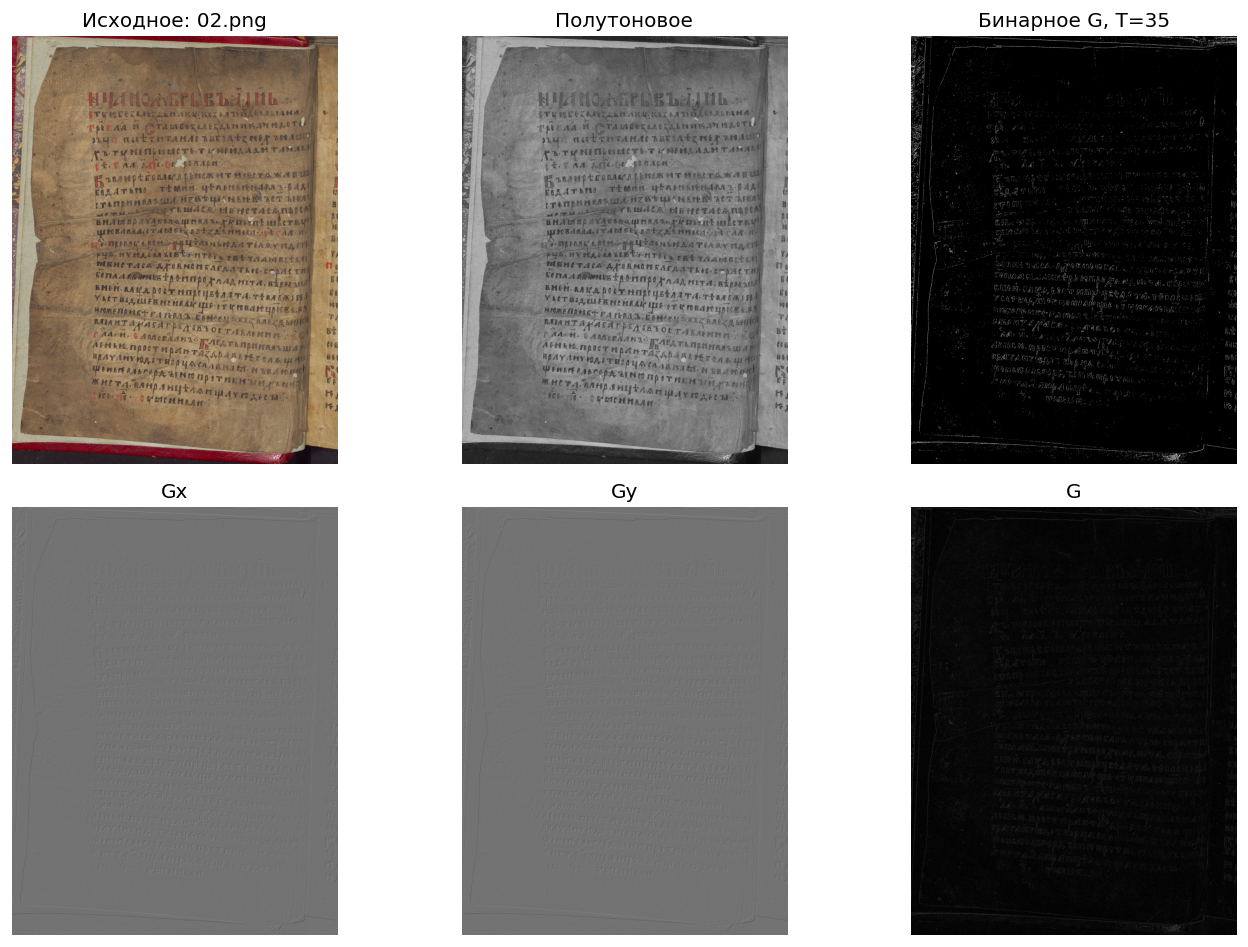

In [5]:
for name, rgb, gray, gx, gy, g, binary in processed:
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title(f"Исходное: {name}")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(gray, cmap="gray", vmin=0, vmax=255)
    axes[0, 1].set_title("Полутоновое")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(binary, cmap="gray", vmin=0, vmax=255)
    axes[0, 2].set_title(f"Бинарное G, T={THRESHOLD}")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(gx, cmap="gray", vmin=0, vmax=255)
    axes[1, 0].set_title("Gx")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(gy, cmap="gray", vmin=0, vmax=255)
    axes[1, 1].set_title("Gy")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(g, cmap="gray", vmin=0, vmax=255)
    axes[1, 2].set_title("G")
    axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()
